
Running: H2 (UCCSD + SLSQP)
Qubits: 4 | Params: 3
Electrons: (1, 1) | Orbitals: 2
Core energy: 0.000000 H
Max evals: 300 | Early stop: 50 evals without improvement


/home/ayhambadr/qbind-env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/ayhambadr/qbind-env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)



[CONVERGED] Energy: -1.137306 H | Error: 0.000036 H | Time: 0.9s

Running: LiH (FreezeCore + UCCSD + SLSQP)
Qubits: 10 | Params: 24
Electrons: (1, 1) | Orbitals: 5
Core energy: -7.798707 H
Max evals: 300 | Early stop: 50 evals without improvement


/home/ayhambadr/qbind-env/lib/python3.14/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/ayhambadr/qbind-env/lib/python3.14/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


  Eval  20: E = -7.751860 H  (best: -7.751860)
  Eval  40: E = -7.879084 H  (best: -7.879084)
  Eval  60: E = -7.879673 H  (best: -7.879673)
  Eval  80: E = -7.881356 H  (best: -7.881356)
  Eval 100: E = -7.881946 H  (best: -7.881946)
  Eval 120: E = -7.881983 H  (best: -7.881983)
  Eval 140: E = -7.881995 H  (best: -7.881994)

[CONVERGED] Energy: -7.881995 H | Error: 0.000367 H | Time: 2521.9s


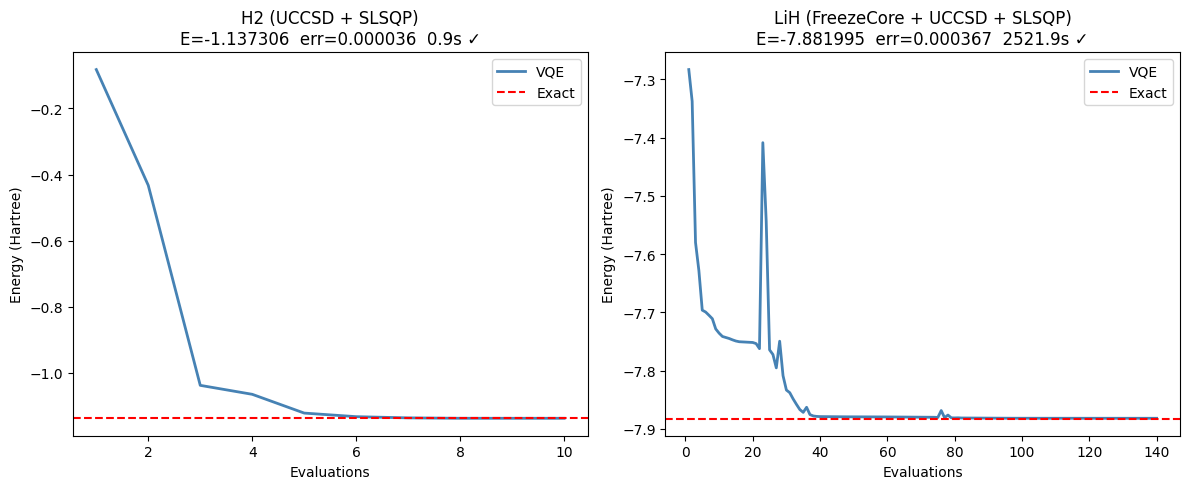


Method<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<< Energy<<<<<< Error<<<<<<< Time<<<<<< Status
--------------------------------------------------------------------------------
H2 (UCCSD + SLSQP)                         -1.137306    0.000036     0.9       s  OK
LiH (FreezeCore + UCCSD + SLSQP)           -7.881995    0.000367     2521.9    s  OK


In [1]:
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock, UCC
from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient   # CHANGED
from qiskit_algorithms.utils import algorithm_globals
from qiskit.primitives import StatevectorEstimator
import matplotlib.pyplot as plt
import time

algorithm_globals.random_seed = 42


def run_vqe(atom, transformer=None, basis="sto-3g", reference_energy=None, 
            excitation_type="SD", label="", max_evals=300):
    
    start = time.time()
    driver = PySCFDriver(atom=atom, basis=basis)
    problem = driver.run()
    
    if transformer:
        problem = transformer.transform(problem)
    
    mapper = JordanWignerMapper()
    qubit_op = mapper.map(problem.hamiltonian.second_q_op())
    nuclear_repulsion = problem.hamiltonian.nuclear_repulsion_energy
    
    # CHANGED: use the frozen-core constant, NOT reference_energy
    core_energy = problem.hamiltonian.constants.get('FreezeCoreTransformer', 0.0)

    hf_state = HartreeFock(
        num_spatial_orbitals=problem.num_spatial_orbitals,
        num_particles=problem.num_particles,
        qubit_mapper=mapper
    )
    
    if excitation_type == "SD":
        ansatz = UCCSD(
            num_spatial_orbitals=problem.num_spatial_orbitals,
            num_particles=problem.num_particles,
            qubit_mapper=mapper,
            initial_state=hf_state
        )
    else:
        ansatz = UCC(
            num_spatial_orbitals=problem.num_spatial_orbitals,
            num_particles=problem.num_particles,
            qubit_mapper=mapper,
            excitation_type="S",
            initial_state=hf_state
        )

    counts, values = [], []
    best_energy = float('inf')
    stall_count = 0
    
    def callback(eval_count, parameters, mean, std):
        nonlocal best_energy, stall_count
        total_e = mean + nuclear_repulsion + core_energy
        counts.append(eval_count)
        values.append(total_e)
        
        if total_e < best_energy - 1e-6:
            best_energy = total_e
            stall_count = 0
        else:
            stall_count += 1
            
        if eval_count % 20 == 0 or stall_count == 50:
            print(f"  Eval {eval_count:3d}: E = {total_e:.6f} H  (best: {best_energy:.6f})")
            
        if stall_count >= 50:
            raise StopIteration(f"Early stop: no improvement for 50 evaluations")

    print(f"\n{'='*60}")
    print(f"Running: {label}")
    print(f"Qubits: {qubit_op.num_qubits} | Params: {ansatz.num_parameters}")
    print(f"Electrons: {problem.num_particles} | Orbitals: {problem.num_spatial_orbitals}")
    print(f"Core energy: {core_energy:.6f} H")
    print(f"Max evals: {max_evals} | Early stop: 50 evals without improvement")

    opt = SLSQP(maxiter=max_evals, ftol=1e-8)
    
    # CHANGED: exact parameter-shift gradient (no slow finite differences)
    estimator = StatevectorEstimator()
    gradient = ParamShiftEstimatorGradient(estimator)
    
    vqe = VQE(estimator, ansatz, opt, gradient=gradient, callback=callback)  # CHANGED
    
    try:
        result = vqe.compute_minimum_eigenvalue(qubit_op)
        converged = True
    except StopIteration:
        print("  >>> Early stopping triggered!")
        result = None
        converged = False

    if values:
        best_idx = values.index(min(values))
        total_energy = values[best_idx]
    else:
        total_energy = float('inf')
        
    elapsed = time.time() - start
    error = abs(total_energy - reference_energy) if reference_energy else None
    
    status = "CONVERGED" if converged else "EARLY_STOP"
    print(f"\n[{status}] Energy: {total_energy:.6f} H | Error: {error:.6f} H | Time: {elapsed:.1f}s")

    return {
        'label': label,
        'energy': total_energy,
        'error': error,
        'qubits': qubit_op.num_qubits,
        'params': ansatz.num_parameters,
        'time': elapsed,
        'counts': counts,
        'values': values,
        'reference': reference_energy,
        'converged': converged
    }


# ============================================================
# RUNS
# ============================================================

results = []

results.append(run_vqe(
    "H 0 0 0; H 0 0 0.735",
    reference_energy=-1.137270,
    label="H2 (UCCSD + SLSQP)"
))

results.append(run_vqe(
    "Li 0 0 0; H 0 0 1.594",
    transformer=FreezeCoreTransformer(),
    reference_energy=-7.882362,
    excitation_type="SD",
    label="LiH (FreezeCore + UCCSD + SLSQP)",
    max_evals=300
))


# ============================================================
# PLOT
# ============================================================

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
if n == 1:
    axes = [axes]

for i, res in enumerate(results):
    ax = axes[i]
    ax.plot(res['counts'], res['values'], color='steelblue', linewidth=2, label='VQE')
    if res['reference']:
        ax.axhline(y=res['reference'], color='red', linestyle='--', label='Exact')
    status = "✓" if res['converged'] else "⚠ early stop"
    err_str = f"{res['error']:.6f}" if res['error'] is not None else "N/A"
    ax.set_title(f"{res['label']}\nE={res['energy']:.6f}  err={err_str}  {res['time']:.1f}s {status}")
    ax.set_xlabel('Evaluations')
    ax.set_ylabel('Energy (Hartree)')
    ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# TABLE
# ============================================================

print(f"\n{'='*80}")
print(f"{'Method':<<42} {'Energy':<<12} {'Error':<<12} {'Time':<<10} {'Status'}")
print(f"{'-'*80}")
for r in results:
    err_str = f"{r['error']:.6f}" if r['error'] is not None else "N/A"
    print(f"{r['label']:<42} {r['energy']:<12.6f} {err_str:<12} {r['time']:<10.1f}s  {'OK' if r['converged'] else 'LIMITED'}")
print(f"{'='*80}")